# scLDM.CD4 Quickstart Inference Tutorial

## Learning Goals

Perform inference and generate scRNA-seq perturbation data using a pre-trained checkpoint. 

## Prerequisites

**Compute resources:** Inference with the released pre-trained checkpoint has been tested on NVIDIA A100, H100, and A6000 GPUs. CPU-only inference is not currently supported; we recommend using at least one GPU for inference. 

**General requirements:** This tutorial assumes that you have already downloaded the pre-trained checkpoint and associated config file from Hugging Face, set up a virtual environment, and updated paths in yaml files as described in the repo's README. 

## Setup

First, import the necessary modules.

In [1]:
import os
import sys
from pathlib import Path

from notebook_inference import NotebookInference, inference

# For displaying results
import anndata as ad
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

/home/jason.perera/projects/git_repos/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Define the required paths.

In [2]:
# Paths for inference
INFERENCE_CONFIG_PATH = "../experiments/config"
INFERENCE_CONFIG_NAME = "inference_fm"
CHECKPOINT_PATH = "../model/last.ckpt"  # modify as necessary
OUTPUT_DIR = "../inference_outputs"  # modify as necessary

In [3]:
# Paths for visualization
TEST_ADATA_PATH = "../quickstart_data/test_hvg/adata_1_1k.h5ad"  # modify as necessary

## Run Model Inference

Inference will generate a new adata, which will also be saved to the output directory.

In [4]:
generated_adata = inference(
    config_path=INFERENCE_CONFIG_PATH,
    config_name=INFERENCE_CONFIG_NAME,
    checkpoint_path=CHECKPOINT_PATH,
    output_dir=OUTPUT_DIR,
    dataset_generation_idx=0,
    seed=42,
    batch_size=32,
    device="cuda",
    overrides=["model.batch_size=32"]
)

print(f"Generated {generated_adata.n_obs} cells")
print(f"Features: {generated_adata.n_vars}")

Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32/32 0:04:36 • 0:00:00 0.13it/s

/home/jason.perera/projects/git_repos/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/cellarium/ml/utilities/
distributed.py:52: UserWarning: Distributed package is available but the default process group has not been 
initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(

INFO     Processing generation output                                                                              
✓ Saved 4000 cells to ../inference_outputs/marson_hvg_generated_0.h5ad
Generated 4000 cells
Features: 3699


Note: if you run out of GPU memory, try reducing `batch_size`.

2k cells run in ~4 minutes on a single H100 GPU and ~17 minutes on a single A6000 GPU

## Model Outputs and Visualization

Examine the generated adata.

In [5]:
generated_adata

AnnData object with n_obs × n_vars = 4000 × 3699
    obs: 'donor_id', 'guide_target_ensembl', 'experimental_perturbation_time_point', 'dataset', 'generation_idx'
    obsm: 'z'

Note that the generated adata contains two datasets: `generated_unconditional` and `generated_conditional`.

In [6]:
generated_adata.obs["dataset"].value_counts()

dataset
generated_conditional      2000
generated_unconditional    2000
Name: count, dtype: int64

Load test data to compare with generated data.

In [7]:
test_adata = sc.read_h5ad(TEST_ADATA_PATH)

Add a `"dataset"` column to the test data so we can compare it with the generated data.

In [8]:
test_adata.obs["dataset"] = "test"

Concatenate the two adatas so we can visualize the true and generated cells together.

In [9]:
adata = ad.concat([generated_adata, test_adata], join="outer")

Run standard processing steps.

In [10]:
sc.pp.normalize_total(adata, target_sum=10_000)
sc.pp.log1p(adata)

In [11]:
sc.pp.pca(adata)

Plot PCA, colored by dataset.

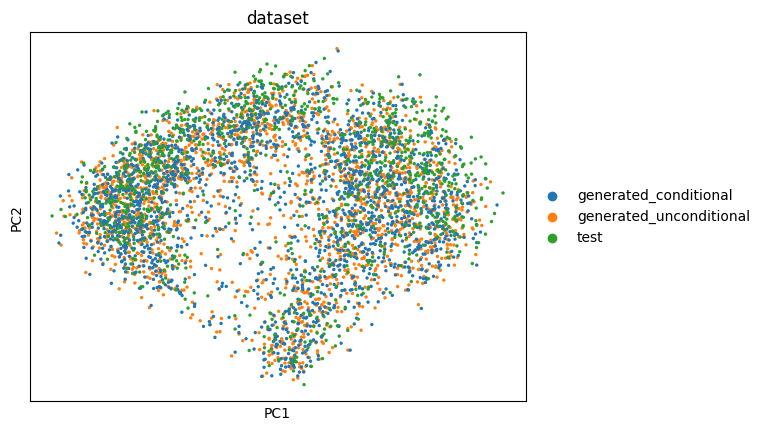

In [12]:
sc.pl.pca(adata, color="dataset")

In [13]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

Plot PCA, colored by experimental time point.

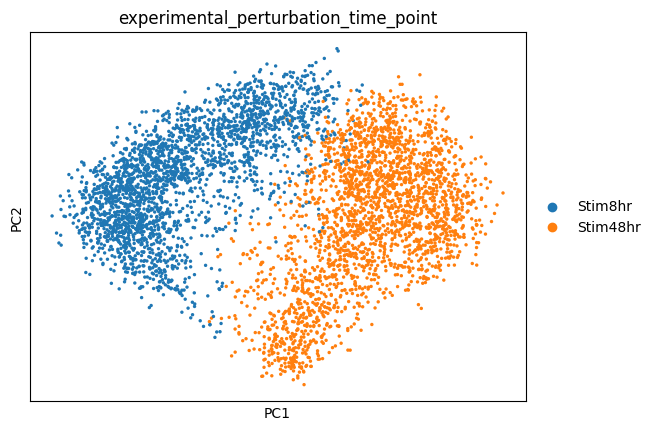

In [14]:
sc.pl.pca(adata, color="experimental_perturbation_time_point")

Plot UMAP, colored by dataset.

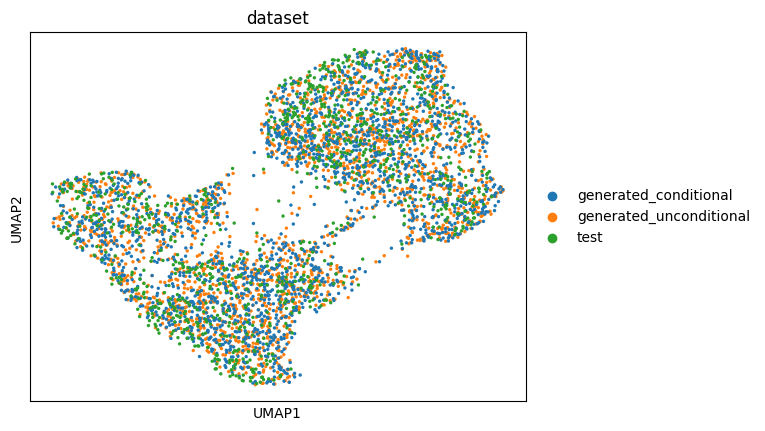

In [15]:
sc.pl.umap(adata, color="dataset")

Plot UMAP, colored by experimental time point.

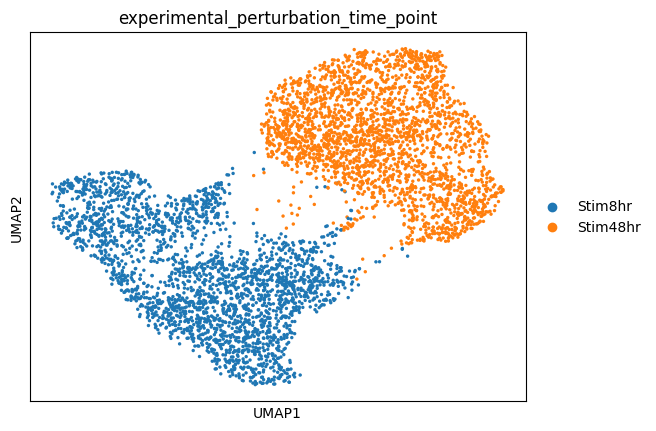

In [16]:
sc.pl.umap(adata, color="experimental_perturbation_time_point")

Plot UMAP, colored by donor.

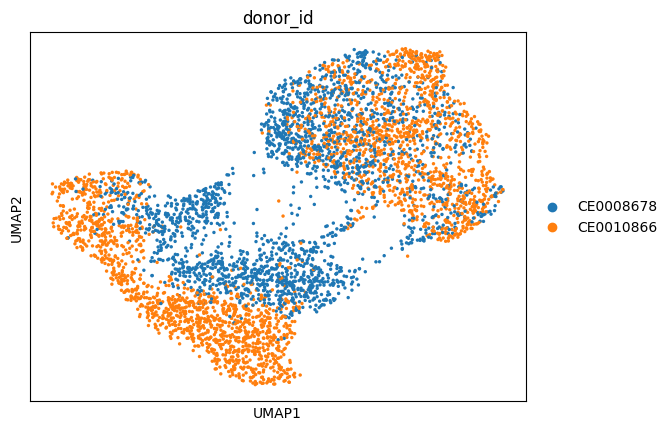

In [17]:
sc.pl.umap(adata, color="donor_id")

## Contact

For issues with this tutorial, please contact Mei Knudson (knudsonm@uchicago.edu).

Special thanks to Kavita Kulkarni and Jason Perera for their consultation on this quickstart.

## Responsible Use

We are committed to advancing the responsible development and use of artificial intelligence. Please follow our [Acceptable Use Policy](https://www.google.com/url?q=https%3A%2F%2Fvirtualcellmodels.cziscience.com%2Facceptable-use-policy) when engaging with our services.